
# Eva Foundation Model — 5-Fold Cross-Validation Pipeline
 Author: Julia Oesterle
 Date: May 2026

 Approach:
 - Spatial token embeddings from 224x224 patches centered on each cell
 - Neighbourhood context is acceptable — output is one label per cell mask
 - 5-fold cross-validation using predefined folds.json splits
 - Classifier trained on train-fold images, predicted on test-fold images
 - Output: 5 x Prediction_fold_X.csv

 Pipeline per fold:
- 1. Load train/test image lists from folds.json
- 2. Extract spatial token features for ALL images (cached, reused across folds)
- 3. For each fold: train logistic regression on train cells, predict test cells
- 4. Save Prediction_fold_X.csv with cell_id, image_id, predicted_phenotype



Cell 1: Environment Setup

In [ ]:
import os
os.environ['CUDA_HOME'] = '/usr/local/cuda-12.3'
os.environ['LD_LIBRARY_PATH'] = '/usr/local/cuda-12.3/lib64:' + os.environ.get('LD_LIBRARY_PATH', '')
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

import torch
import numpy as np
import pandas as pd
import tifffile
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.patches import Patch
import seaborn as sns
import umap
import json
import random
from tqdm import tqdm
from collections import defaultdict
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, f1_score

print("CUDA available:", torch.cuda.is_available())
print("GPU count:", torch.cuda.device_count())
device = "cuda:1" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

/home/juliaoesterle/eva/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


CUDA available: True
GPU count: 2
Using device: cuda:1


Cell 2: Load Eva Model

In [ ]:

import sys
sys.path.insert(0, '/home/juliaoesterle/eva/project')

from omegaconf import OmegaConf
from Eva.utils import load_from_hf

os.chdir("/home/juliaoesterle/eva/project")

conf  = OmegaConf.load("config.yaml")
model = load_from_hf(repo_id="yandrewl/Eva", conf=conf, device=device)
model.eval()
print("Model loaded on:", next(model.parameters()).device)

Checkpoint downloaded to: /home/juliaoesterle/.cache/huggingface/hub/models--yandrewl--Eva/snapshots/a466c781c1edf63595e85f18e8f3f9669200186a/Eva_model.ckpt
Model loaded successfully from HuggingFace Hub
Model loaded on: cuda:1


Cell 3: Define Markers

In [ ]:
biomarkers_all = [
    "MPO", "HistoneH3", "SMA", "CD16", "CD38", "HLADR", "CD27", "CD15",
    "CD45RA", "CD163", "B2M", "CD20", "CD68", "Ido1", "CD3", "LAG3",
    "CD11c", "PD1", "PDGFRb", "CD7", "GrzB", "PDL1", "TCF7", "CD45RO",
    "FOXP3", "ICOS", "CD8a", "CarbonicAnhydrase", "CD33", "Ki67",
    "VISTA", "CD40", "CD4", "CD14", "Ecad", "CD303", "CD206",
    "cleavedPARP", "DNA1", "DNA2"
]

dna_channels  = {'DNA1', 'DNA2', 'HistoneH3'}
clean_indices = [i for i, m in enumerate(biomarkers_all) if m not in dna_channels]
biomarkers    = [m for m in biomarkers_all if m not in dna_channels]
print(f"Using {len(biomarkers)} markers (excluded: {dna_channels})")

Using 37 markers (excluded: {'DNA1', 'DNA2', 'HistoneH3'})


Cell 4: Paths

In [ ]:

NPZ_DIR    = "/home/juliaoesterle/data/phenotyping_benchmark/IMMUcan/CellTypes/data/images/"
MASK_DIR   = "/home/juliaoesterle/data/phenotyping_benchmark/IMMUcan/segmentation/"
LABELS_DIR = "/home/juliaoesterle/data/phenotyping_benchmark/IMMUcan/CellTypes/cells2labels/"
FOLDS_FILE = "/home/juliaoesterle/data/phenotyping_benchmark/IMMUcan/CellTypes/folds.json"
OUTPUT_DIR = "/home/juliaoesterle/eva/project/figures/kfold_pipeline/"
CACHE_DIR  = "/home/juliaoesterle/eva/project/figures/kfold_pipeline/cache/"
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(CACHE_DIR,  exist_ok=True)

label_map_df = pd.read_csv("/home/juliaoesterle/data/phenotyping_benchmark/IMMUcan/CellTypes/labels_cell_type.csv")
label_map    = dict(zip(label_map_df['label'], label_map_df['phenotype']))

PATCH_SIZE = 224


Cell 5: Load Folds 

In [ ]:
with open(FOLDS_FILE) as f:
    folds_data = json.load(f)

N_FOLDS = 5
folds = []
for i in range(N_FOLDS):
    folds.append({
        'train': folds_data[f'fold_{i}_train_set'],
        'test':  folds_data[f'fold_{i}_test_set']
    })

# All unique images across all folds
all_images = sorted(set(
    img for fold in folds for split in ['train', 'test'] for img in fold[split]
))
print(f"Total unique images across all folds: {len(all_images)}")
for i, fold in enumerate(folds):
    print(f"  Fold {i}: {len(fold['train'])} train, {len(fold['test'])} test images")

Total unique images across all folds: 179
  Fold 0: 143 train, 36 test images
  Fold 1: 143 train, 36 test images
  Fold 2: 143 train, 36 test images
  Fold 3: 143 train, 36 test images
  Fold 4: 144 train, 35 test images


Cell 6: Detect Token Shape

In [ ]:
print("\nDetecting Eva token output shape...")
test_npz = NPZ_DIR + all_images[0] + '.npz'
test_img = np.load(test_npz)['data'].astype(np.float32)
test_img = test_img[clean_indices]
test_img = test_img / (test_img.max() + 1e-8)
test_img = test_img.transpose(1, 2, 0)
test_tile = test_img[:PATCH_SIZE, :PATCH_SIZE, :]
test_tensor = torch.from_numpy(test_tile).unsqueeze(0).to(device)

with torch.no_grad():
    token_out, _ = model.model.forward_encoder(
        test_tensor.permute(0, 3, 1, 2), [biomarkers]
    )

B, C, N_plus_1, D = token_out.shape
N_spatial  = N_plus_1 - 1
GRID_SIZE  = int(np.sqrt(N_spatial))
TOKEN_SIZE = PATCH_SIZE // GRID_SIZE

print(f"Token shape: {token_out.shape}")
print(f"  Spatial grid: {GRID_SIZE}x{GRID_SIZE} = {N_spatial} tokens")
print(f"  Each token: {TOKEN_SIZE}x{TOKEN_SIZE} pixels | D={D}")

del test_tensor, token_out
torch.cuda.empty_cache()


Detecting Eva token output shape...
Token shape: torch.Size([1, 1, 785, 768])
  Spatial grid: 28x28 = 784 tokens
  Each token: 8x8 pixels | D=768


Cell 7: Spatial Token Map Extraction

In [ ]:

def extract_token_map(img, model, biomarkers, device,
                      patch_size, grid_size, token_size, feat_dim):
    """
    Tile image into overlapping 224x224 patches, run Eva,
    map tokens back to pixel space. Returns (H, W, D) token map.
    """
    H, W, C     = img.shape
    feat_accum  = np.zeros((H, W, feat_dim), dtype=np.float32)
    count_accum = np.zeros((H, W),           dtype=np.float32)

    stride   = patch_size // 2
    y_starts = list(range(0, max(1, H - patch_size + 1), stride))
    x_starts = list(range(0, max(1, W - patch_size + 1), stride))
    if not y_starts or y_starts[-1] + patch_size < H:
        y_starts.append(max(0, H - patch_size))
    if not x_starts or x_starts[-1] + patch_size < W:
        x_starts.append(max(0, W - patch_size))
    y_starts = sorted(set(y_starts))
    x_starts = sorted(set(x_starts))

    for y0 in y_starts:
        for x0 in x_starts:
            y1 = min(y0 + patch_size, H)
            x1 = min(x0 + patch_size, W)
            tile = img[y0:y1, x0:x1, :]
            if tile.shape[0] < patch_size or tile.shape[1] < patch_size:
                tile = np.pad(tile, (
                    (0, patch_size - tile.shape[0]),
                    (0, patch_size - tile.shape[1]),
                    (0, 0)
                ))

            tile_tensor = torch.from_numpy(tile).unsqueeze(0).to(device)
            with torch.no_grad():
                token_out, _ = model.model.forward_encoder(
                    tile_tensor.permute(0, 3, 1, 2), [biomarkers]
                )
            spatial = token_out[0, :, 1:, :].mean(dim=0).cpu().numpy()
            token_grid = spatial.reshape(grid_size, grid_size, feat_dim)

            for ti in range(grid_size):
                for tj in range(grid_size):
                    py0 = y0 + ti * token_size
                    py1 = min(py0 + token_size, H)
                    px0 = x0 + tj * token_size
                    px1 = min(px0 + token_size, W)
                    if py0 >= H or px0 >= W:
                        continue
                    feat_accum[py0:py1, px0:px1, :]  += token_grid[ti, tj, :]
                    count_accum[py0:py1, px0:px1]    += 1

            del tile_tensor, token_out
            torch.cuda.empty_cache()

    count_accum = np.maximum(count_accum, 1)
    return feat_accum / count_accum[:, :, np.newaxis]


def extract_cell_features(token_map, mask, cell_labels, label_map):
    """Average token features over each cell's pixels."""
    features, labels, cell_ids = [], [], []
    unique_cells = np.unique(mask)
    unique_cells = unique_cells[unique_cells > 0]
    for cell_id in unique_cells:
        if cell_id - 1 >= len(cell_labels):
            continue
        label       = cell_labels[cell_id - 1]
        cell_pixels = mask == cell_id
        cell_feat   = token_map[cell_pixels].mean(axis=0)
        features.append(cell_feat)
        labels.append(label_map.get(label, 'Unknown'))
        cell_ids.append(int(cell_id))
    return features, labels, cell_ids

Cell 8: Extract Features for ALL Images (cached)

In [ ]:

print(f"\nExtracting features for {len(all_images)} images...")
img_feature_store = {}  # image_name → (features_arr, labels_list, cell_ids_list)

for img_name in tqdm(all_images, desc="Feature extraction"):
    cache_feat = CACHE_DIR + f"{img_name}_feat.npy"
    cache_meta = CACHE_DIR + f"{img_name}_meta.csv"

    if os.path.exists(cache_feat) and os.path.exists(cache_meta):
        feats = np.load(cache_feat)
        meta  = pd.read_csv(cache_meta)
        img_feature_store[img_name] = (
            feats,
            meta['label'].tolist(),
            meta['cell_id'].tolist()
        )
        continue

    npz_file   = NPZ_DIR   + img_name + '.npz'
    mask_file  = MASK_DIR  + img_name + '.tiff'
    label_file = LABELS_DIR + img_name + '.txt'

    if not all(os.path.exists(f) for f in [npz_file, mask_file, label_file]):
        print(f"  Skipping {img_name} — missing files")
        continue

    img = np.load(npz_file)['data'].astype(np.float32)
    img = img[clean_indices]
    img = img / (img.max() + 1e-8)
    img = img.transpose(1, 2, 0)

    mask = tifffile.imread(mask_file)
    with open(label_file) as f:
        cell_labels = [int(line.strip()) for line in f.readlines()]

    token_map = extract_token_map(
        img, model, biomarkers, device,
        PATCH_SIZE, GRID_SIZE, TOKEN_SIZE, D
    )

    feats, labels, cell_ids = extract_cell_features(
        token_map, mask, cell_labels, label_map
    )

    feats_arr = np.array(feats)
    np.save(cache_feat, feats_arr)
    pd.DataFrame({
        'image_id': [img_name] * len(cell_ids),
        'cell_id':  cell_ids,
        'label':    labels
    }).to_csv(cache_meta, index=False)

    img_feature_store[img_name] = (feats_arr, labels, cell_ids)

print(f"Features ready for {len(img_feature_store)} images")



Extracting features for 179 images...


Feature extraction: 100%|██████████| 179/179 [00:00<00:00, 333.57it/s]

Features ready for 179 images


Cell 9: 5-Fold Cross-Validation

In [ ]:

print("\nRunning 5-fold cross-validation...")

all_fold_predictions = []  # collect all predictions across folds
fold_reports = {}

for fold_idx in range(N_FOLDS):
    print(f"\n── Fold {fold_idx} ──────────────────────────────")
    train_images = folds[fold_idx]['train']
    test_images  = folds[fold_idx]['test']

    # Collect train cells
    X_train, y_train = [], []
    for img_name in train_images:
        if img_name not in img_feature_store:
            continue
        feats, labels, _ = img_feature_store[img_name]
        mask_known = np.array(labels) != 'Unknown'
        X_train.extend(feats[mask_known])
        y_train.extend(np.array(labels)[mask_known])

    X_train = np.array(X_train)
    y_train = np.array(y_train)
    print(f"  Train: {len(X_train)} cells from {len(train_images)} images")

    # Train classifier
    clf = LogisticRegression(max_iter=1000, random_state=42)
    clf.fit(X_train, y_train)

    # Predict test cells
    fold_preds = []
    for img_name in test_images:
        if img_name not in img_feature_store:
            continue
        feats, labels, cell_ids = img_feature_store[img_name]

        # Predict ALL cells (including Unknown — classifier assigns best label)
        y_pred_img  = clf.predict(feats)
        y_proba_img = clf.predict_proba(feats)

        for cell_id, true_label, pred_label, proba in zip(
            cell_ids, labels, y_pred_img, y_proba_img
        ):
            fold_preds.append({
                'image_id':            img_name,
                'cell_id':             cell_id,
                'true_phenotype':      true_label,
                'predicted_phenotype': pred_label,
                'confidence':          proba.max(),
                'fold':                fold_idx
            })

    fold_df = pd.DataFrame(fold_preds)
    print(f"  Test:  {len(fold_df)} cells from {len(test_images)} images")

    # Save fold prediction CSV
    fold_csv = OUTPUT_DIR + f"Prediction_fold_{fold_idx}.csv"
    fold_df.to_csv(fold_csv, index=False)
    print(f"  Saved: Prediction_fold_{fold_idx}.csv")

    # Evaluate on known labels only
    known = fold_df[fold_df['true_phenotype'] != 'Unknown']
    report = classification_report(
        known['true_phenotype'], known['predicted_phenotype'],
        output_dict=True, zero_division=0
    )
    fold_reports[fold_idx] = report
    print(f"  Accuracy: {report['accuracy']:.3f} | Macro F1: {report['macro avg']['f1-score']:.3f}")

    all_fold_predictions.append(fold_df)

# Combine all folds
all_preds_df = pd.concat(all_fold_predictions, ignore_index=True)
all_preds_df.to_csv(OUTPUT_DIR + "Prediction_all_folds.csv", index=False)
print(f"\nSaved Prediction_all_folds.csv ({len(all_preds_df)} total cells)")



Running 5-fold cross-validation...

── Fold 0 ──────────────────────────────
  Train: 362439 cells from 143 images


/home/juliaoesterle/eva/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


  Test:  95250 cells from 36 images
  Saved: Prediction_fold_0.csv
  Accuracy: 0.709 | Macro F1: 0.443

── Fold 1 ──────────────────────────────
  Train: 359437 cells from 143 images


/home/juliaoesterle/eva/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


  Test:  98258 cells from 36 images
  Saved: Prediction_fold_1.csv
  Accuracy: 0.714 | Macro F1: 0.436

── Fold 2 ──────────────────────────────
  Train: 364584 cells from 143 images


...

  Test:  93166 cells from 36 images
  Saved: Prediction_fold_2.csv
  Accuracy: 0.711 | Macro F1: 0.467

── Fold 3 ──────────────────────────────
  Train: 373171 cells from 143 images


/home/juliaoesterle/eva/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


  Test:  84688 cells from 36 images
  Saved: Prediction_fold_3.csv
  Accuracy: 0.679 | Macro F1: 0.439

── Fold 4 ──────────────────────────────
  Train: 368837 cells from 144 images


/home/juliaoesterle/eva/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


  Test:  88924 cells from 35 images
  Saved: Prediction_fold_4.csv
  Accuracy: 0.708 | Macro F1: 0.444

Saved Prediction_all_folds.csv (460286 total cells)


Cell 10: Aggregate Results Across Folds

In [ ]:
#10: Aggregate Results Across Folds 
print("\nAggregating results across folds...")

# Per-fold accuracy and macro F1
fold_summary = pd.DataFrame({
    'fold':      range(N_FOLDS),
    'accuracy':  [fold_reports[i]['accuracy']                  for i in range(N_FOLDS)],
    'macro_f1':  [fold_reports[i]['macro avg']['f1-score']     for i in range(N_FOLDS)],
    'weighted_f1': [fold_reports[i]['weighted avg']['f1-score'] for i in range(N_FOLDS)],
})
fold_summary.loc['mean'] = fold_summary.mean()
fold_summary.loc['std']  = fold_summary.std()
print(fold_summary.to_string())
fold_summary.to_csv(OUTPUT_DIR + "fold_summary.csv")



Aggregating results across folds...
          fold  accuracy  macro_f1  weighted_f1
0     0.000000  0.709468  0.443076     0.689457
1     1.000000  0.713821  0.436094     0.699496
2     2.000000  0.711314  0.467432     0.696782
3     3.000000  0.679496  0.439332     0.659744
4     4.000000  0.707963  0.444067     0.693220
mean  2.000000  0.704412  0.446000     0.687740
std   1.414214  0.012610  0.011084     0.014400


Cell 11: Plot 1 - Per-Fold Accuracy

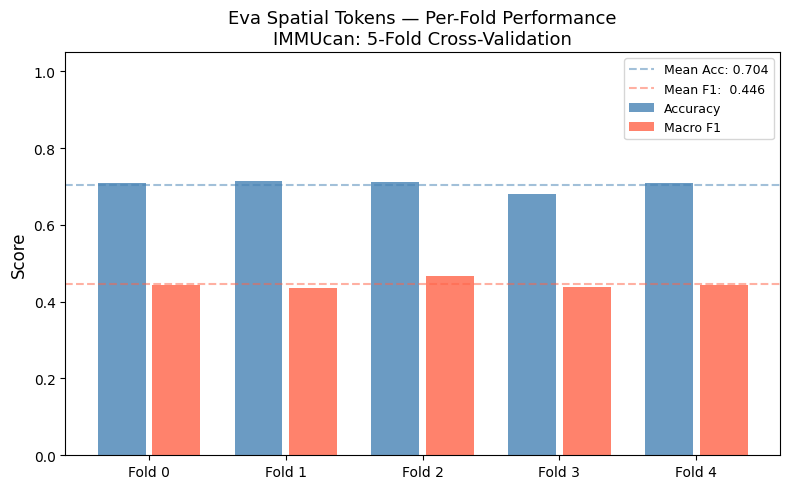

Saved Plot 1


In [ ]:

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(N_FOLDS)
ax.bar(x - 0.2, fold_summary['accuracy'][:N_FOLDS],   0.35, label='Accuracy',   color='steelblue', alpha=0.8)
ax.bar(x + 0.2, fold_summary['macro_f1'][:N_FOLDS],   0.35, label='Macro F1',   color='tomato',    alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels([f'Fold {i}' for i in range(N_FOLDS)])
ax.set_ylabel('Score', fontsize=12)
ax.set_ylim(0, 1.05)
ax.set_title('Eva Spatial Tokens — Per-Fold Performance\nIMMUcan: 5-Fold Cross-Validation', fontsize=13)
ax.axhline(y=fold_summary['accuracy'][:N_FOLDS].mean(), color='steelblue',
           linestyle='--', alpha=0.5, label=f'Mean Acc: {fold_summary["accuracy"][:N_FOLDS].mean():.3f}')
ax.axhline(y=fold_summary['macro_f1'][:N_FOLDS].mean(), color='tomato',
           linestyle='--', alpha=0.5, label=f'Mean F1:  {fold_summary["macro_f1"][:N_FOLDS].mean():.3f}')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(OUTPUT_DIR + "plot_01_per_fold_accuracy.png", dpi=150)
plt.show()
print("Saved Plot 1")

Cell 12: Plot 2 - Mean F1 per Cell Type across Folds 

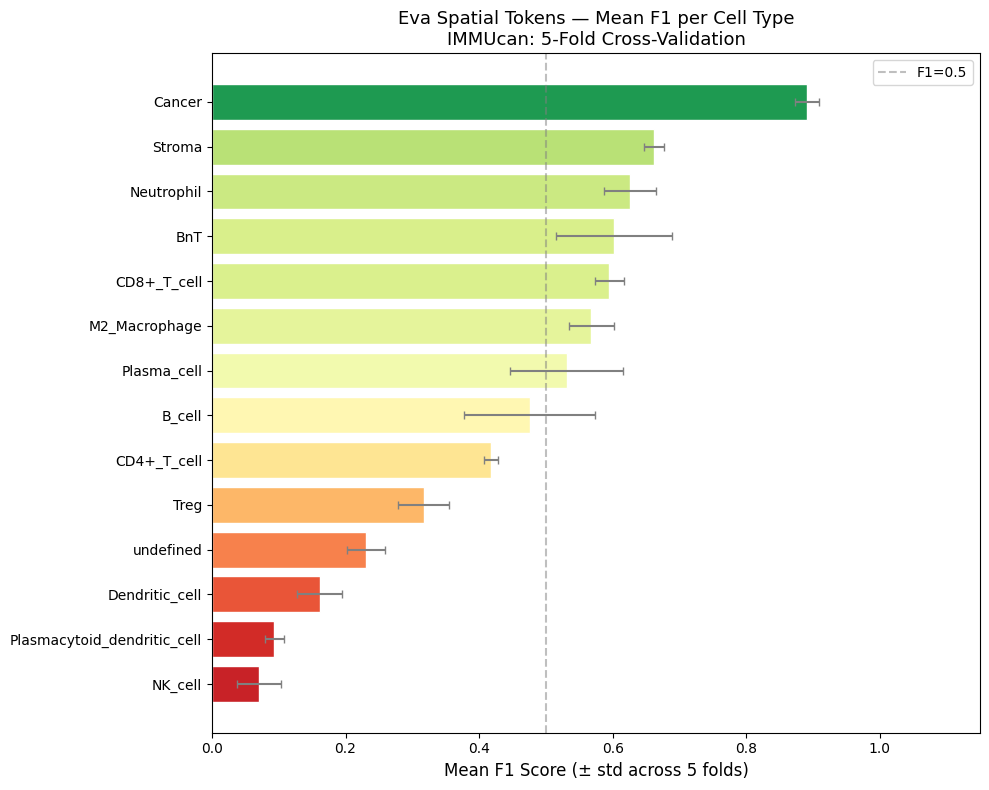

Saved Plot 2


In [ ]:

cell_type_f1 = defaultdict(list)
for i in range(N_FOLDS):
    for ct, metrics in fold_reports[i].items():
        if ct in ['accuracy', 'macro avg', 'weighted avg']:
            continue
        cell_type_f1[ct].append(metrics['f1-score'])

ct_f1_df = pd.DataFrame({
    'cell_type': list(cell_type_f1.keys()),
    'mean_f1':   [np.mean(v) for v in cell_type_f1.values()],
    'std_f1':    [np.std(v)  for v in cell_type_f1.values()],
}).sort_values('mean_f1', ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(ct_f1_df['cell_type'], ct_f1_df['mean_f1'],
               color=plt.cm.RdYlGn(ct_f1_df['mean_f1']), edgecolor='white', xerr=ct_f1_df['std_f1'],
               error_kw={'ecolor': 'gray', 'capsize': 3})
ax.set_xlim(0, 1.15)
ax.set_xlabel('Mean F1 Score (± std across 5 folds)', fontsize=12)
ax.set_title('Eva Spatial Tokens — Mean F1 per Cell Type\nIMMUcan: 5-Fold Cross-Validation', fontsize=13)
ax.axvline(x=0.5, color='gray', linestyle='--', alpha=0.5, label='F1=0.5')
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR + "plot_02_mean_F1_per_celltype.png", dpi=150)
plt.show()
print("Saved Plot 2")

Cell 13: Plot 3 - Confusion Matrix (all folds combined)

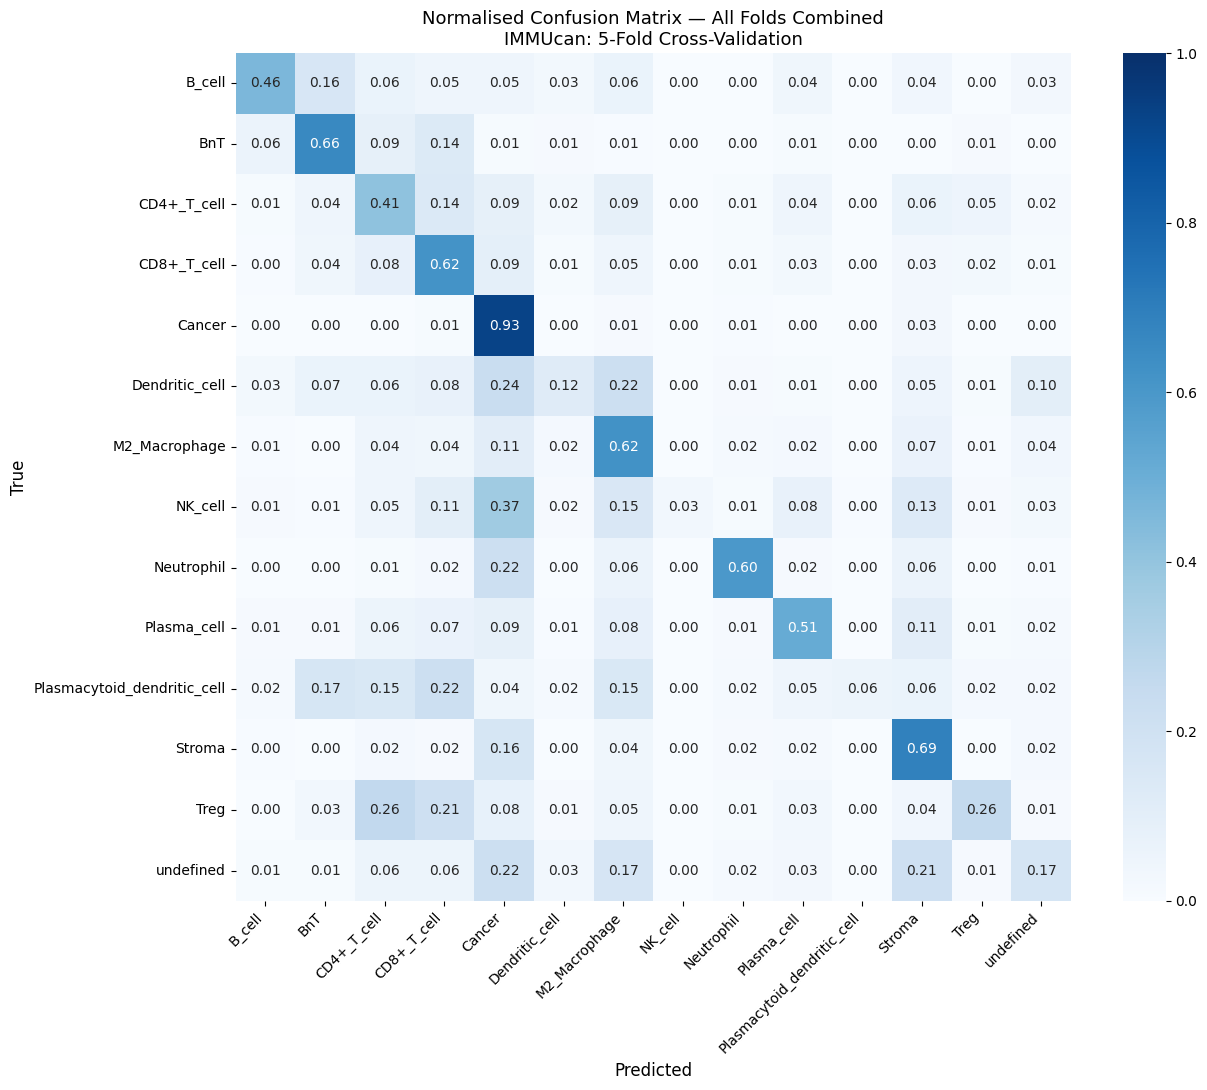

Saved Plot 3


In [ ]:

known_all = all_preds_df[all_preds_df['true_phenotype'] != 'Unknown']
classes   = sorted(known_all['true_phenotype'].unique())
cm_matrix = confusion_matrix(known_all['true_phenotype'],
                              known_all['predicted_phenotype'], labels=classes)
cm_norm   = cm_matrix.astype(float) / cm_matrix.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=classes, yticklabels=classes, ax=ax, vmin=0, vmax=1)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('True', fontsize=12)
ax.set_title('Normalised Confusion Matrix — All Folds Combined\nIMMUcan: 5-Fold Cross-Validation', fontsize=13)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(OUTPUT_DIR + "plot_03_confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved Plot 3")

Cell 14: Plot 4 - F1 per Cell Type per Fold (heatmap)

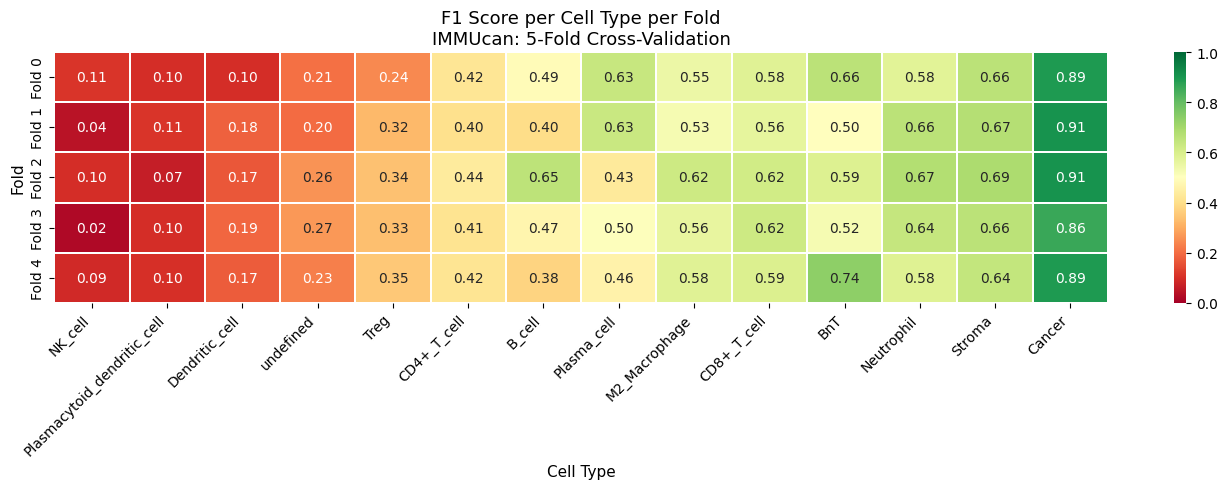

Saved Plot 4


In [ ]:

f1_heatmap_data = {}
for i in range(N_FOLDS):
    f1_heatmap_data[f'Fold {i}'] = {
        ct: fold_reports[i].get(ct, {}).get('f1-score', 0)
        for ct in ct_f1_df['cell_type']
    }
f1_heatmap_df = pd.DataFrame(f1_heatmap_data).T

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(f1_heatmap_df, annot=True, fmt='.2f', cmap='RdYlGn',
            ax=ax, vmin=0, vmax=1, linewidths=0.3)
ax.set_title('F1 Score per Cell Type per Fold\nIMMUcan: 5-Fold Cross-Validation', fontsize=13)
ax.set_xlabel('Cell Type', fontsize=11)
ax.set_ylabel('Fold', fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(OUTPUT_DIR + "plot_04_F1_per_fold_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved Plot 4")

Cell 15: Plot 5 - UMAP (all folds, subsampled)

Fitting UMAP (subsampled)...


/home/juliaoesterle/eva/venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


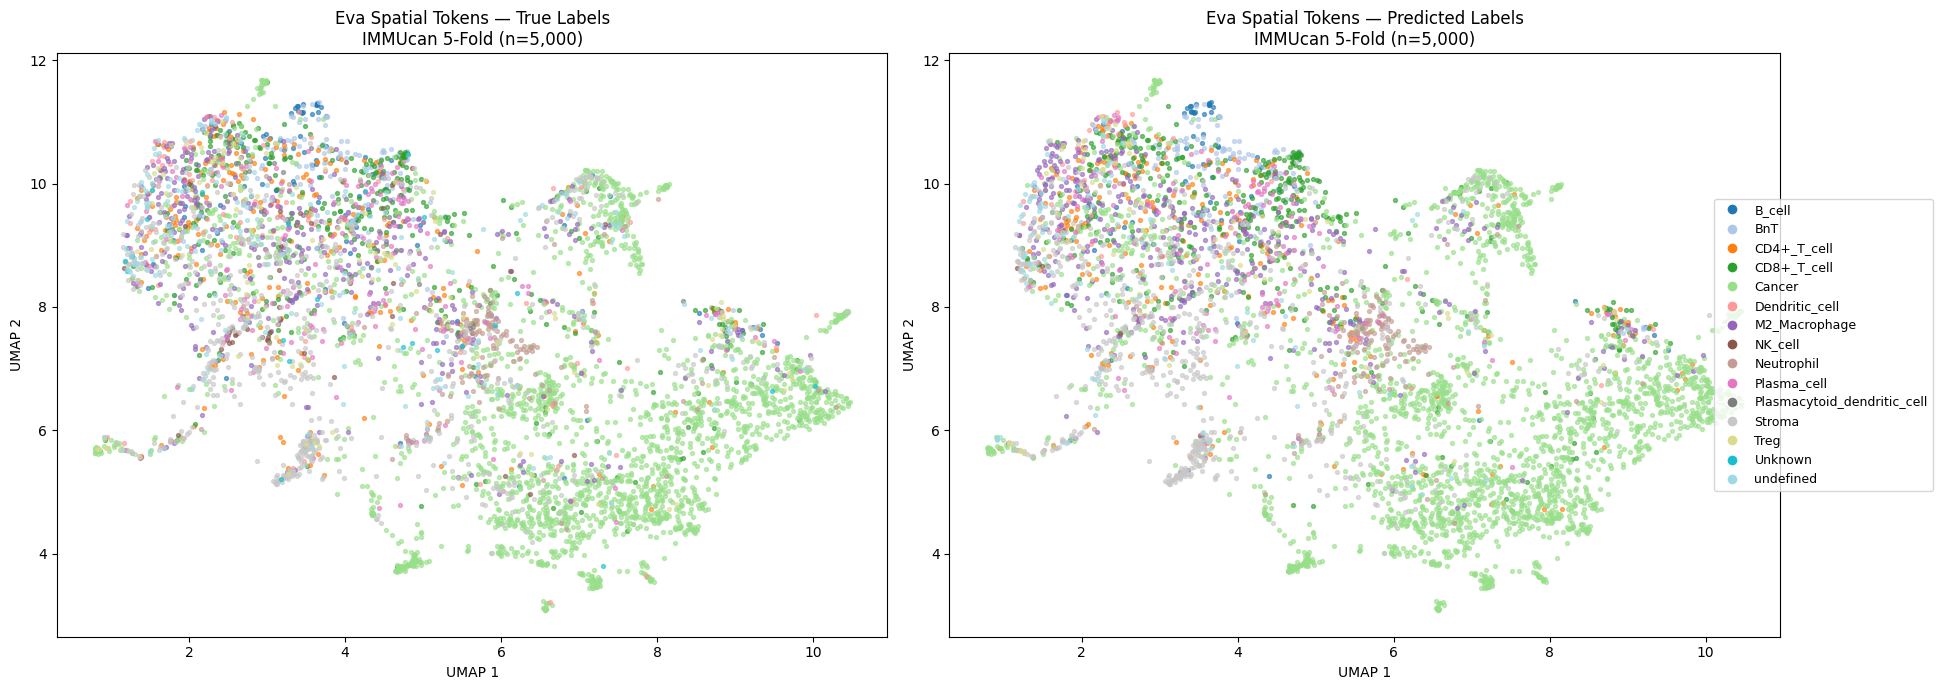

Saved Plot 5


In [ ]:

print("Fitting UMAP (subsampled)...")
# Collect all features + labels from test sets across folds
all_test_feats, all_test_labels, all_test_preds = [], [], []
for fold_idx in range(N_FOLDS):
    for img_name in folds[fold_idx]['test']:
        if img_name not in img_feature_store:
            continue
        feats, labels, _ = img_feature_store[img_name]
        all_test_feats.extend(feats)
        all_test_labels.extend(labels)

all_test_feats  = np.array(all_test_feats)
all_test_labels = np.array(all_test_labels)
all_test_preds  = all_preds_df['predicted_phenotype'].values

# Subsample for UMAP
np.random.seed(42)
n_sub   = min(5000, len(all_test_feats))
sub_idx = np.random.choice(len(all_test_feats), n_sub, replace=False)
X_sub   = all_test_feats[sub_idx]
y_sub_true = all_test_labels[sub_idx]
y_sub_pred = all_test_preds[sub_idx]

reducer   = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
embedding = reducer.fit_transform(X_sub)

unique_types = sorted(set(y_sub_true) | set(y_sub_pred))
colors       = plt.cm.tab20(np.linspace(0, 1, len(unique_types)))
color_map    = dict(zip(unique_types, colors))

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for ax, labels, title in zip(axes,
    [y_sub_true, y_sub_pred], ['True Labels', 'Predicted Labels']):
    for ct in unique_types:
        idx = labels == ct
        ax.scatter(embedding[idx, 0], embedding[idx, 1],
                   c=[color_map[ct]], label=ct, alpha=0.6, s=8)
    ax.set_title(f'Eva Spatial Tokens — {title}\nIMMUcan 5-Fold (n={n_sub:,})', fontsize=12)
    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')

handles = [plt.Line2D([0], [0], marker='o', color='w',
           markerfacecolor=color_map[ct], markersize=8, label=ct)
           for ct in unique_types]
fig.legend(handles=handles, loc='center right', bbox_to_anchor=(1.08, 0.5), fontsize=9)
plt.tight_layout()
plt.savefig(OUTPUT_DIR + "plot_05_UMAP_true_vs_predicted.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved Plot 5")



Final Summary

In [ ]:

print("\n" + "="*60)
print("✓ 5-Fold Cross-Validation Complete!")
print("="*60)
print(f"\nMean Accuracy:    {fold_summary['accuracy'][:N_FOLDS].mean():.3f} ± {fold_summary['accuracy'][:N_FOLDS].std():.3f}")
print(f"Mean Macro F1:    {fold_summary['macro_f1'][:N_FOLDS].mean():.3f} ± {fold_summary['macro_f1'][:N_FOLDS].std():.3f}")
print(f"Mean Weighted F1: {fold_summary['weighted_f1'][:N_FOLDS].mean():.3f} ± {fold_summary['weighted_f1'][:N_FOLDS].std():.3f}")
print(f"\nOutputs saved to: {OUTPUT_DIR}")
print("\nFiles:")
print("  Prediction_fold_0.csv → Prediction_fold_4.csv  (one per fold)")
print("  Prediction_all_folds.csv                        (combined)")
print("  fold_summary.csv                                (metrics per fold)")
print("  plot_01_per_fold_accuracy.png")
print("  plot_02_mean_F1_per_celltype.png")
print("  plot_03_confusion_matrix.png")
print("  plot_04_F1_per_fold_heatmap.png")
print("  plot_05_UMAP_true_vs_predicted.png")


✓ 5-Fold Cross-Validation Complete!

Mean Accuracy:    0.704 ± 0.014
Mean Macro F1:    0.446 ± 0.012
Mean Weighted F1: 0.688 ± 0.016

Outputs saved to: /home/juliaoesterle/eva/project/figures/kfold_pipeline/

Files:
  Prediction_fold_0.csv → Prediction_fold_4.csv  (one per fold)
  Prediction_all_folds.csv                        (combined)
  fold_summary.csv                                (metrics per fold)
  plot_01_per_fold_accuracy.png
  plot_02_mean_F1_per_celltype.png
  plot_03_confusion_matrix.png
  plot_04_F1_per_fold_heatmap.png
  plot_05_UMAP_true_vs_predicted.png


Add-On: Save Vectors + Leidsen Clustering 

Cell A1: SetUp

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc

CACHE_DIR  = "/home/juliaoesterle/eva/project/figures/kfold_pipeline/cache/"
OUTPUT_DIR = "/home/juliaoesterle/eva/project/figures/kfold_pipeline/"
os.makedirs(OUTPUT_DIR, exist_ok=True)

Cell A2: Load all cached feature vectors

In [ ]:
print("Loading all cached feature vectors...")

all_feats_list    = []
all_labels_list   = []
all_cell_ids_list = []
all_img_ids_list  = []

# Find all cached feature files
cache_feat_files = sorted([
    f for f in os.listdir(CACHE_DIR) if f.endswith('_feat.npy')
])
print(f"Found {len(cache_feat_files)} cached images")

for feat_file in cache_feat_files:
    img_name  = feat_file.replace('_feat.npy', '')
    meta_file = CACHE_DIR + img_name + '_meta.csv'
    feat_path = CACHE_DIR + feat_file

    if not os.path.exists(meta_file):
        print(f"  Missing meta for {img_name}, skipping")
        continue

    feats = np.load(feat_path)
    meta  = pd.read_csv(meta_file)

    all_feats_list.extend(feats)
    all_labels_list.extend(meta['label'].tolist())
    all_cell_ids_list.extend(meta['cell_id'].tolist())
    all_img_ids_list.extend(meta['image_id'].tolist())

all_feats_arr = np.array(all_feats_list)
print(f"Total cells loaded: {len(all_feats_arr):,}")
print(f"Feature dimension: {all_feats_arr.shape[1]}")
print(pd.Series(all_labels_list).value_counts())

Cell A3: Save Raw Feature Vectors

In [ ]:
print("\nSaving raw feature vectors...")

np.save(OUTPUT_DIR + "all_cell_features.npy", all_feats_arr)
pd.DataFrame({
    'image_id': all_img_ids_list,
    'cell_id':  all_cell_ids_list,
    'label':    all_labels_list
}).to_csv(OUTPUT_DIR + "all_cell_metadata.csv", index=False)

print(f"Saved all_cell_features.npy  — shape: {all_feats_arr.shape}")
print(f"Saved all_cell_metadata.csv  — {len(all_feats_arr):,} cells")

Cell A4: Leiden Clustering

In [ ]:
print("\nRunning Leiden clustering on all cell embeddings...")

# Build AnnData — exclude Unknown labels
known_mask = np.array(all_labels_list) != 'Unknown'
X_known    = all_feats_arr[known_mask]
y_known    = np.array(all_labels_list)[known_mask]
print(f"Clustering {len(X_known):,} cells (Unknown excluded)")

adata = sc.AnnData(X=X_known)
adata.obs['true_label'] = pd.Categorical(y_known)

# Subsample for speed if needed
MAX_CELLS = 50000
if len(adata) > MAX_CELLS:
    print(f"  Subsampling to {MAX_CELLS:,} cells for Leiden...")
    sc.pp.subsample(adata, n_obs=MAX_CELLS, random_state=42)

# KNN graph → Leiden → UMAP
print("  Computing KNN graph (n_neighbors=15)...")
sc.pp.neighbors(adata, n_neighbors=15, use_rep='X')
print("  Running Leiden (resolution=0.5)...")
sc.tl.leiden(adata, resolution=0.5, random_state=42)
print(f"  Found {adata.obs['leiden'].nunique()} Leiden clusters")
print("  Computing UMAP...")
sc.tl.umap(adata, random_state=42)

# Save Leiden results
leiden_df = pd.DataFrame({
    'leiden_cluster': adata.obs['leiden'].values,
    'true_label':     adata.obs['true_label'].values,
    'umap_1':         adata.obsm['X_umap'][:, 0],
    'umap_2':         adata.obsm['X_umap'][:, 1],
})
leiden_df.to_csv(OUTPUT_DIR + "leiden_clusters.csv", index=False)
print("Saved leiden_clusters.csv")

Cell A5: Plot - Leiden Clusters vs True Labels

In [ ]:
print("\nPlotting Leiden clusters vs true labels...")

n_clusters    = leiden_df['leiden_cluster'].nunique()
unique_labels = sorted(leiden_df['true_label'].unique())
cluster_cmap  = dict(zip(sorted(leiden_df['leiden_cluster'].unique()),
                         plt.cm.tab20(np.linspace(0, 1, n_clusters))))
label_cmap    = dict(zip(unique_labels,
                         plt.cm.tab20(np.linspace(0, 1, len(unique_labels)))))

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Left: Leiden clusters
ax = axes[0]
for cl in sorted(leiden_df['leiden_cluster'].unique()):
    idx = leiden_df['leiden_cluster'] == cl
    ax.scatter(leiden_df.loc[idx, 'umap_1'], leiden_df.loc[idx, 'umap_2'],
               c=[cluster_cmap[cl]], s=5, alpha=0.5, label=f'C{cl}')
ax.set_title(f'Leiden Clusters (n={n_clusters}, resolution=0.5)\n'
             'Eva Spatial Token Embeddings', fontsize=12)
ax.set_xlabel('UMAP 1'); ax.set_ylabel('UMAP 2')
ax.legend(fontsize=6, ncol=3, markerscale=2, bbox_to_anchor=(1.01, 1))

# Right: True labels
ax = axes[1]
for lb in unique_labels:
    idx = leiden_df['true_label'] == lb
    ax.scatter(leiden_df.loc[idx, 'umap_1'], leiden_df.loc[idx, 'umap_2'],
               c=[label_cmap[lb]], s=5, alpha=0.5, label=lb)
ax.set_title('True Cell Type Labels\nIMMUcan: 179 Images', fontsize=12)
ax.set_xlabel('UMAP 1'); ax.set_ylabel('UMAP 2')
ax.legend(fontsize=7, markerscale=2, bbox_to_anchor=(1.01, 1))

plt.suptitle('Eva Spatial Tokens — Leiden Clustering vs True Labels\nIMMUcan: 179 Images',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR + "leiden_plot_01_clusters_vs_labels.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved leiden_plot_01_clusters_vs_labels.png")

Cell A6: Plot - Leiden Cluster Composition

In [ ]:
cluster_comp = leiden_df.groupby(
    ['leiden_cluster', 'true_label']
).size().unstack(fill_value=0)
cluster_pct = cluster_comp.div(cluster_comp.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(14, 7))
cluster_pct.plot(kind='bar', stacked=True, ax=ax, colormap='tab20', edgecolor='none')
ax.set_xlabel('Leiden Cluster', fontsize=12)
ax.set_ylabel('% of Cells', fontsize=12)
ax.set_title('Cell Type Composition per Leiden Cluster\n'
             'Eva Spatial Token Embeddings — IMMUcan 179 Images', fontsize=13)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.savefig(OUTPUT_DIR + "leiden_plot_02_cluster_composition.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved leiden_plot_02_cluster_composition.png")

Final Add-On-Summary 

Loading all cached feature vectors...
Found 179 cached images
Total cells loaded: 460,286
Feature dimension: 768
Cancer                         210853
Stroma                          50127
CD8+_T_cell                     35867
M2_Macrophage                   33882
CD4+_T_cell                     25832
undefined                       18867
Plasma_cell                     17972
Neutrophil                      14723
BnT                             13497
Treg                            10809
Dendritic_cell                  10098
B_cell                           8263
NK_cell                          3412
Unknown                          3169
Plasmacytoid_dendritic_cell      2915
Name: count, dtype: int64

Saving raw feature vectors...
Saved all_cell_features.npy  — shape: (460286, 768)
Saved all_cell_metadata.csv  — 460,286 cells

Running Leiden clustering on all cell embeddings...
Clustering 457,117 cells (Unknown excluded)
  Subsampling to 50,000 cells for Leiden...
  Computing KNN graph 

/tmp/ipykernel_3791261/2344635921.py:95: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata, resolution=0.5, random_state=42)


  Found 16 Leiden clusters
  Computing UMAP...
Saved leiden_clusters.csv

Plotting Leiden clusters vs true labels...


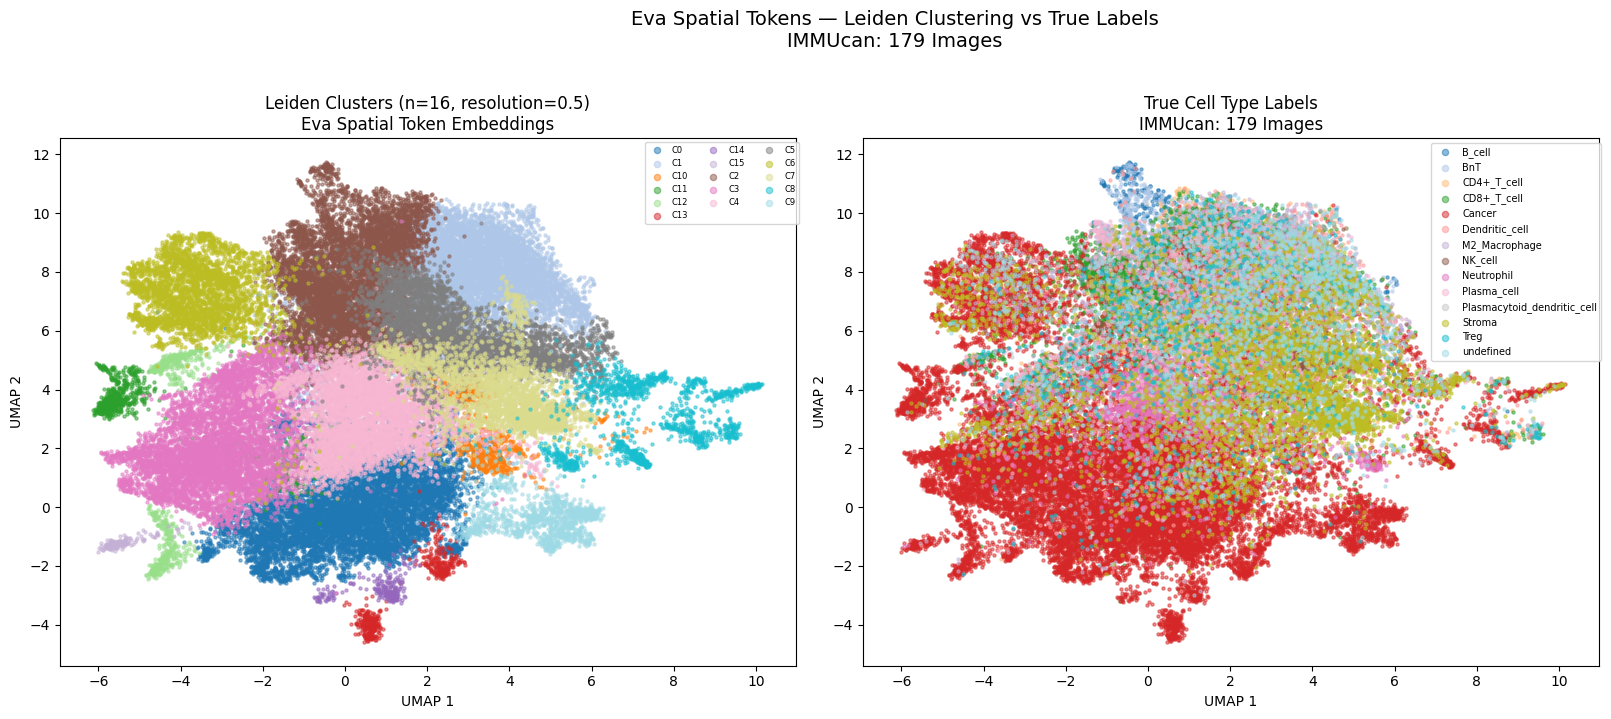

Saved leiden_plot_01_clusters_vs_labels.png


/tmp/ipykernel_3791261/2344635921.py:151: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_comp = leiden_df.groupby(


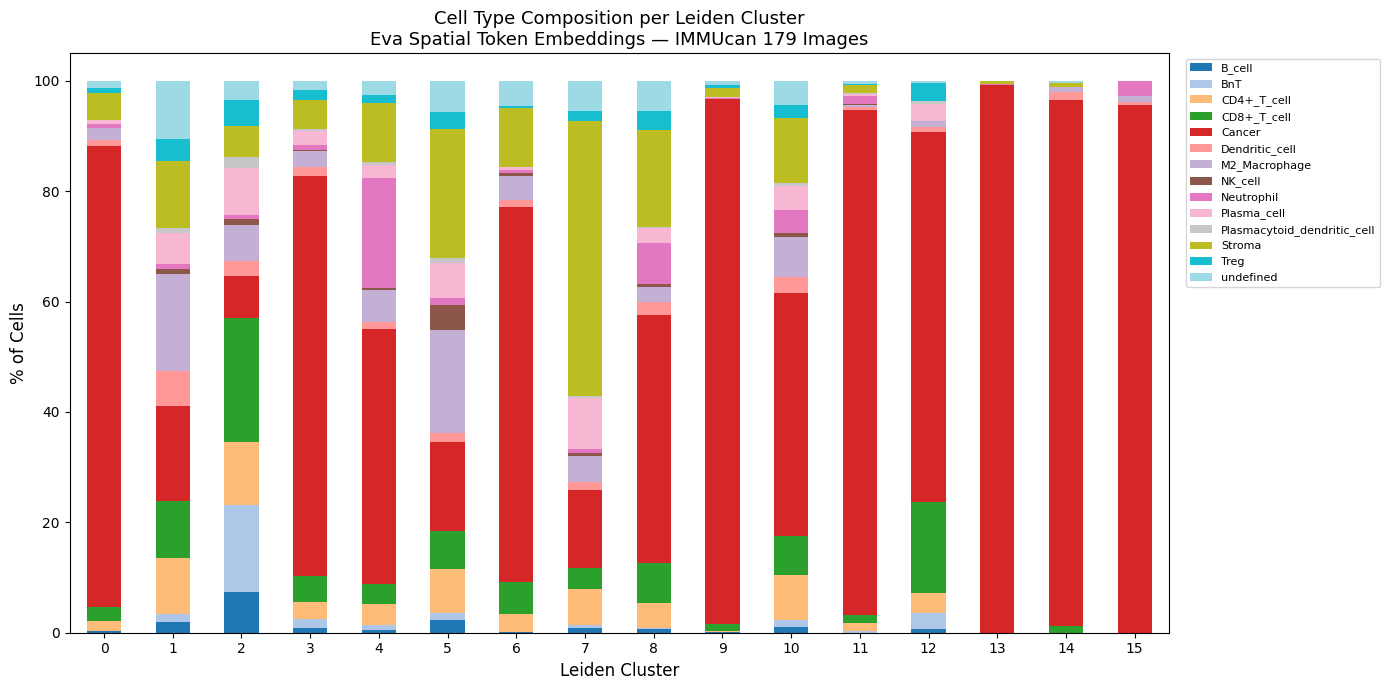

Saved leiden_plot_02_cluster_composition.png

✓ Add-on complete!

New files saved to: /home/juliaoesterle/eva/project/figures/kfold_pipeline/

  all_cell_features.npy              ← raw 768-dim vectors for all cells
  all_cell_metadata.csv              ← image_id, cell_id, label
  leiden_clusters.csv                ← Leiden assignments + UMAP coords
  leiden_plot_01_clusters_vs_labels.png
  leiden_plot_02_cluster_composition.png

Re: Aroj's question about patch size:

Eva's patch_embed layer hard-checks input size:
  assert H == 224 and W == 224

So Eva ONLY accepts 224x224 input. The patch size cannot be
changed without retraining the model.

However, the CONTENT inside the 224x224 can vary:
  - 224x224 tissue tile    → neighbourhood context (v3)
  - 32x32 cell bbox padded → single-cell signal (v5)
  - 64x64 cell bbox padded → more cell context (possible v6)

The padding is always zero, so the model sees black borders
around the actual cell content when using small crops.



In [ ]:

print("\n✓ Add-on complete!")
print(f"\nNew files saved to: {OUTPUT_DIR}")
print("""
  all_cell_features.npy              ← raw 768-dim vectors for all cells
  all_cell_metadata.csv              ← image_id, cell_id, label
  leiden_clusters.csv                ← Leiden assignments + UMAP coords
  leiden_plot_01_clusters_vs_labels.png
  leiden_plot_02_cluster_composition.png
""")
